In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [5]:
# Create State
class batsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int
    sr:float
    bpb:float
    boundary_percent:float
    summary: str

In [19]:
def cal_StrikeRate(state: batsmanState):
    balls = state['balls']
    runs = state['runs']
    sr = (runs/balls)*100
    state['sr'] = sr
    return {'sr':sr}

In [20]:
def cal_boundary_percent(state:batsmanState) :
    fours = state['fours']
    sixes = state['sixes']
    runs = state['runs']
    boundary_percent = (((fours*4) + (sixes*6))/runs) * 100
    state['boundary_percent'] = boundary_percent
    return {'boundary_percent':boundary_percent}

In [21]:
def cal_bpb(state: batsmanState):
    balls = state['balls']
    fours = state['fours']
    sixes = state['sixes']
    bpb = balls /(sixes+fours)
    state['bpb'] = bpb
    return {'bpb':bpb}

In [22]:
def summary(state: batsmanState) -> batsmanState:
    sr = state['sr']
    bpb=state['bpb']
    boundary_percent = state['boundary_percent']
    summary = f"""
    Strike Rate = ${sr} \n
    Boundary Percentage = ${boundary_percent}\n
    Boundary per ball = ${bpb}
    """
    state['summary'] = summary
    return state


In [23]:
# Create Graph
graph = StateGraph(batsmanState)

#Add nodes to graph
graph.add_node('cal_strikeRate',cal_StrikeRate)
graph.add_node('cal_boundary_percent',cal_boundary_percent)
graph.add_node('cal_bpb',cal_bpb)
graph.add_node('summary',summary)

# Add Edges to the Graph
graph.add_edge(START,'cal_boundary_percent')
graph.add_edge(START,'cal_strikeRate')
graph.add_edge(START,'cal_bpb')

graph.add_edge('cal_boundary_percent','summary')
graph.add_edge('cal_strikeRate','summary')
graph.add_edge('cal_bpb','summary')

graph.add_edge('summary',END)

# Compile the graph
workflow = graph.compile()



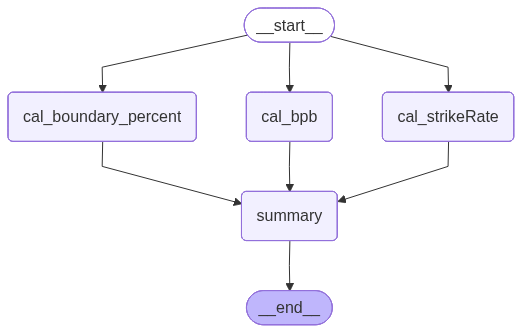

In [12]:
# Visualize the graph 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [24]:
# Execute Graph
initial_state = {
    'runs':100,
    'balls':50,
    'fours':6,
    'sixes':4
}
final_state = workflow.invoke(initial_state)
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percent': 48.0, 'summary': '\n    Strike Rate = $200.0 \n\n    Boundary Percentage = $48.0\n\n    Boundary per ball = $5.0\n    '}
